In [1]:
import pandas as pd
import sys
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

sys.path.insert(0, "../src")
from data_cleaner import DataCleaner
from encoder import Encoder


In [2]:
pd.set_option('display.max_columns', None) # show full dataframe

In [3]:
# import data
train_val = pd.read_csv("../data/training_set_values.csv")
train_label = pd.read_csv("../data/training_set_labels.csv")


# merge train and target data
train_data = pd.merge(train_val, train_label, on="id")

In [4]:
clean = DataCleaner()

cleaned_df = clean.preprocess(train_data)

c:\Users\Owner\Python\Data_Circle\notebooks\../src\data_cleaner.py:22: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dataframe["date_recorded"] = pd.to_datetime(dataframe['date_recorded'])
2025-11-08 16:09:36,027 - INFO - Removed -9 invalid rows (negative pump_age). Remaining rows: 59391
2025-11-08 16:09:36,032 - INFO - Data cleaning completed.


In [5]:
cleaned_df

,quantity_group,region,payment_type,extraction_type_class,management,quality_group,pump_age,status_group
0,enough,Iringa,annually,gravity,vwc,good,12.000000,functional
1,insufficient,Mara,never pay,gravity,wug,good,3.000000,functional
2,enough,Manyara,per bucket,gravity,vwc,good,4.000000,functional
3,dry,Mtwara,never pay,submersible,vwc,good,27.000000,non functional
4,seasonal,Kagera,never pay,gravity,other,good,14.185314,functional
...,...,...,...,...,...,...,...,...
59386,enough,Kilimanjaro,per bucket,gravity,water board,good,14.000000,functional
59387,enough,Iringa,annually,gravity,vwc,good,15.000000,functional
59388,enough,Mbeya,monthly,handpump,vwc,fluoride,14.185314,functional
59389,insufficient,Dodoma,never pay,handpump,vwc,good,14.185314,functional


In [6]:
encode = Encoder()

encoded_df = encode.encode_categorcial_value(cleaned_df)
encoded_df

,pump_age,quantity_group_dry,quantity_group_enough,quantity_group_insufficient,quantity_group_seasonal,quantity_group_unknown,region_Arusha,region_Dar es Salaam,region_Dodoma,region_Iringa,region_Kagera,region_Kigoma,region_Kilimanjaro,region_Lindi,region_Manyara,region_Mara,region_Mbeya,region_Morogoro,region_Mtwara,region_Mwanza,region_Pwani,region_Rukwa,region_Ruvuma,region_Shinyanga,region_Singida,region_Tabora,region_Tanga,payment_type_annually,payment_type_monthly,payment_type_never pay,payment_type_on failure,payment_type_other,payment_type_per bucket,payment_type_unknown,extraction_type_class_gravity,extraction_type_class_handpump,extraction_type_class_motorpump,extraction_type_class_other,extraction_type_class_rope pump,extraction_type_class_submersible,extraction_type_class_wind-powered,management_company,management_other,management_other - school,management_parastatal,management_private operator,management_trust,management_unknown,management_vwc,management_water authority,management_water board,management_wua,management_wug,quality_group_colored,quality_group_fluoride,quality_group_good,quality_group_milky,quality_group_salty,quality_group_unknown,status_group_functional,status_group_functional needs repair,status_group_non functional
0,12.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,4.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,27.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,14.185314,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59386,14.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
59387,15.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
59388,14.185314,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
59389,14.185314,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [21]:

### Logistic regression with softmax
# model = LogisticRegression(C=1e5, solver='newton-cg')

# define a range of c values usinf logarithmis scale
# c_space = np.logspace(-5, 8, 15)    
# param_grid = {'C': c_space}

 # define the gridsearch to tune hyperparameter
# classifier = GridSearchCV(model, param_grid)


### Linear classifiers (SVM, logistic regression, etc.) with SGD training.
# One vs. Rest classifcation
# model = SGDClassifier(max_iter=1000, tol=1e-3)

# define a range of c values usinf logarithmis scale
# c_space = np.logspace(-5, 8, 15)    
# param_grid = {'C': c_space}

 # define the gridsearch to tune hyperparameter
# classifier = GridSearchCV(model, param_grid)

### Decision tree
# Source: https://www.datacamp.com/tutorial/decision-tree-classification-python
classifier = DecisionTreeClassifier()


# param_dist = {
#     "max_depth": [3, None],
#     "max_features": randint(1, 9),
#     "min_samples_leaf": randint(1, 9),
#     "criterion": ["gini", "entropy"]
#     }   

# classifier = RandomizedSearchCV(model, param_dist)


Without hyperparameter tuning:
1. Decision tree
2. Linear classifier with SGD training
3. Logistic regression with softmax

- All model struggled with predicting "need to repair", especially logistic regression -> oversampling improve this
- Adding pump_age improved the model very slightly

In [22]:
from imblearn.over_sampling import RandomOverSampler

def oversampling(X: np.array, y: np.array) -> np.array:
    """ Randomly oversample minority class """
    
    # Printing number of samples in
    # each class before Over-Sampling
    # t = [(d) for d in y if d==0]
    # s = [(d) for d in y if d==1]
    print('Before Over-Sampling: ')
    print(np.count_nonzero(y == 1, axis=0))
    

    # Over Sampling Minority class
    OverS = RandomOverSampler(random_state=42)

    # Fit predictor (x variable)
    # and target (y variable) using fit_resample()
    X_Over, y_Over = OverS.fit_resample(X, y)

    # Printing number of samples in
    # each class after Over-Sampling
    # t = [(d) for d in Y_Over if d==0]
    # s = [(d) for d in Y_Over if d==1]
    print('After Over-Sampling: ')
    print(np.count_nonzero(y_Over == 1, axis=0))
    
    return X_Over, y_Over

In [24]:
# model base line

# separte feature and target values
target_colunns = ["status_group_functional", "status_group_functional needs repair", "status_group_non functional"]
X = encoded_df.drop(target_colunns, axis=1).to_numpy()
y = encoded_df[target_colunns].to_numpy()

X, y = oversampling(X, y)

# define number of fold
kf = KFold(n_splits=10)

y_test_all = []
y_pred_all = []
iteration = 1

# save the mapping of status group
mapping = {}
for idx, col in enumerate(y):
    mapping[idx] = col

# apply K-fold cross validation
# https://neptune.ai/blog/cross-validation-in-machine-learning-how-to-do-it-right

for train_index, test_index in kf.split(X):
    
    print(f"ITERATION {iteration} / {kf.n_splits}")
    
    # split data into train and test data
    print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    
    # convert 3d array into 1d array since model can output only 1d array
    y_train = np.argmax(y_train, axis=1)
    y_test = np.argmax(y_test, axis=1)
    
    # train a model
    classifier.fit(X_train, y_train)
    
    # predict pump status
    y_pred = classifier.predict(X_test)
    
    # print("Tuned Hyperparameters: {}".format(classifier.best_params_))
    
    # show accuracy
    # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
    acc_score = accuracy_score(y_test, y_pred, normalize=True)
    print("accuracy_score: ", acc_score)
    
    # save all true and predicted value
    y_test_all.append(y_test)
    y_pred_all.append(y_pred)
    
    iteration += 1

Before Over-Sampling: 
[32255  4317 22819]
After Over-Sampling: 
[32255 32255 32255]
ITERATION 1 / 10
TRAIN: [ 9677  9678  9679 ... 96762 96763 96764] TEST: [   0    1    2 ... 9674 9675 9676]
accuracy_score:  0.6840963108401364
ITERATION 2 / 10
TRAIN: [    0     1     2 ... 96762 96763 96764] TEST: [ 9677  9678  9679 ... 19351 19352 19353]
accuracy_score:  0.6832696083496952
ITERATION 3 / 10
TRAIN: [    0     1     2 ... 96762 96763 96764] TEST: [19354 19355 19356 ... 29028 29029 29030]
accuracy_score:  0.6855430401984086
ITERATION 4 / 10
TRAIN: [    0     1     2 ... 96762 96763 96764] TEST: [29031 29032 29033 ... 38705 38706 38707]
accuracy_score:  0.6829595949157797
ITERATION 5 / 10
TRAIN: [    0     1     2 ... 96762 96763 96764] TEST: [38708 38709 38710 ... 48382 48383 48384]
accuracy_score:  0.6788260824635735
ITERATION 6 / 10
TRAIN: [    0     1     2 ... 96762 96763 96764] TEST: [48385 48386 48387 ... 58058 58059 58060]
accuracy_score:  0.6755890863993386
ITERATION 7 / 10
TRAI

                                      precision    recall  f1-score   support

             status_group_functional       0.66      0.64      0.65     32255
status_group_functional needs repair       0.67      0.78      0.72     32255
         status_group_non functional       0.81      0.70      0.75     32255

                            accuracy                           0.71     96765
                           macro avg       0.71      0.71      0.71     96765
                        weighted avg       0.71      0.71      0.71     96765



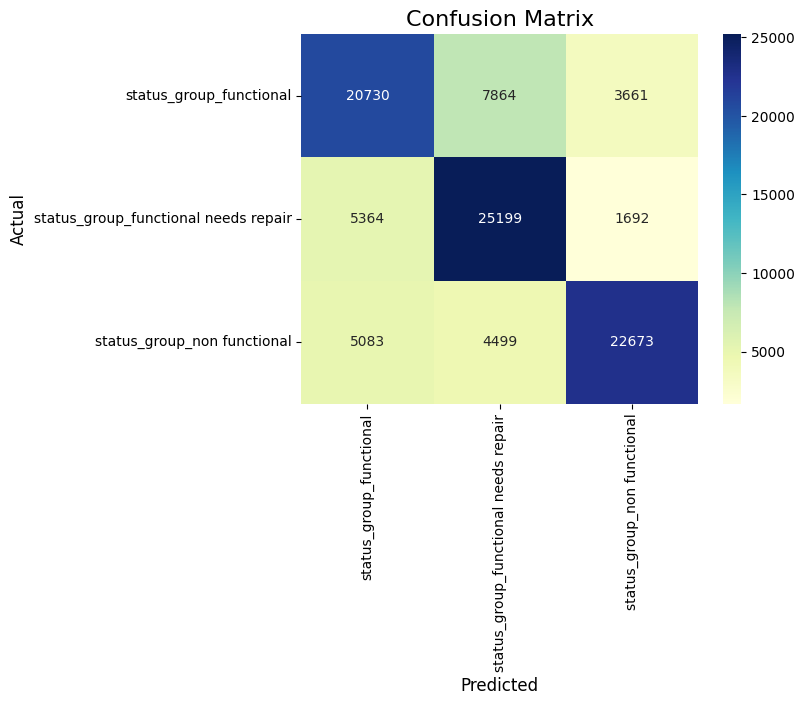

In [25]:
# flat out matrix into single list
y_test_res = [val for y_test in y_test_all for val in y_test]
y_pred_res = [val for y_pred in y_pred_all for val in y_pred]

# create classification report
cr = classification_report(y_test_res, y_pred_res, target_names=target_colunns)
print(cr)


# Create a confusion matrix
# https://medium.com/@sanyagubrani/evaluating-multi-class-classification-model-using-confusion-matrix-in-python-4d9344084dfa
cm = confusion_matrix(y_test_res, y_pred_res)

# Plot the confusion matrix
sns.heatmap(cm, annot=True,fmt='d', cmap='YlGnBu', xticklabels=target_colunns, yticklabels=target_colunns)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix',fontsize=16)
plt.show()


In [ ]:
# plot decision tree

from sklearn.tree import export_graphviz
from six import StringIO
# from sklearn.externals.six import StringIO  
from IPython.display import Image  
import pydotplus

dot_data = StringIO()
export_graphviz(classifier, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True,feature_names = X.columns, class_names=['0','1','2'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
graph.write_png('decision_tree.png')
Image(graph.create_png())